# Search: Solving a Maze Using a Goal-based Agent

Student Name: Ashley Sturm

I have used the following AI tools: Copilot for debugging

I understand that my submission needs to be my own work: AS

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file.


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze.

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.**
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state.
* **Discrete** means that we have a **finite set of states.** The maze has a finite set
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible.

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [948]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [949]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`.

In [950]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

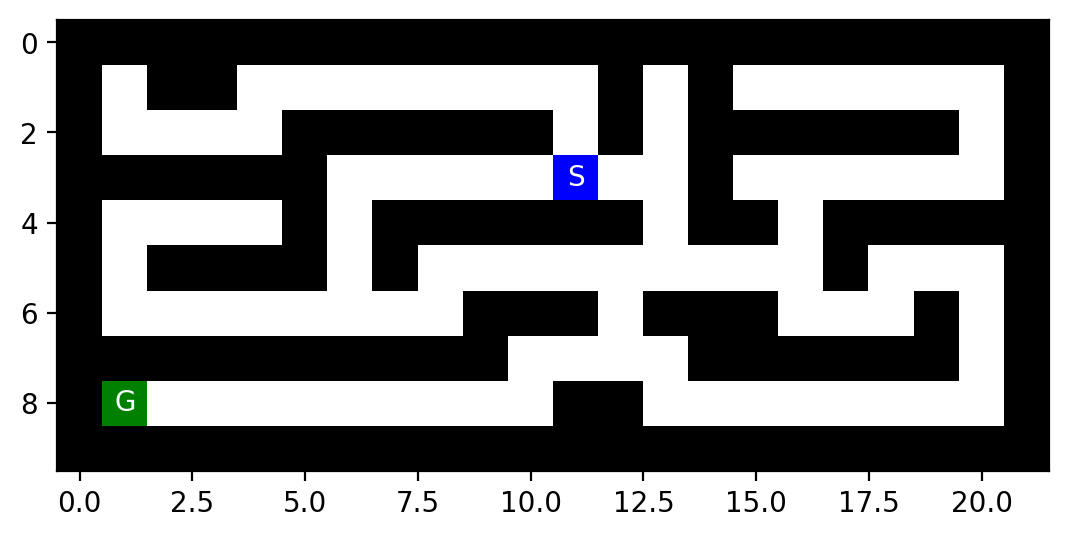

In [951]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [952]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [953]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes. This needs ffmpeg to be installed.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the 

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step.

In [954]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0

        # check if plan is completed
        if self.progress >= len(self.plan):
            raise Exception("Completed Plan. No more planned actions")

        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [955]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['S', 'E', 'E', 'W', 'S', 'N', 'E', 'E', 'N', 'N']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [956]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: N
Following plan... step 1: S
Following plan... step 2: E
Following plan... step 3: E
Following plan... step 4: E
Following plan... step 5: N
Following plan... step 6: S
Following plan... step 7: W
Following plan... step 8: E
Following plan... step 9: S
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python.
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [957]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)

        path.reverse()

        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the
    - [small maze](small_maze.txt),
    - [medium maze](medium_maze.txt),
    - [large maze](large_maze.txt),
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate.

*Note:* You can swich the next block from code to Markdown and use formating.

In [958]:
# Your answer goes here

* Initial state: This is the start position of the agent.
start = mh.find_pos(maze, what="S")

* Actions: A = {N, E, S, W}

* Transition model: T(s,a) = s', which is the position of the agent after applying an action.

* Goal state: This is the goal position in the maze.
goal = mh.find_pos(maze, what="G")

* Path cost: Each move has a cost of one, we calculate the number of actions taken for the total cost.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

In [959]:
# Your answer goes here

* n: The number of legal positions the agent can be in. count all non-wall squares.
* d: length of the shortest path cost to the goal. measure the solution depth of BFS.
* m: maximum length path to the goal before termination. track the maximum depth reached throughout the sort.
* b: <= 4. count the legal actions the agent can take, and take the maximum.

## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking.
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [960]:
from collections import deque

def expand(problem_maze, node):
  actions = {
      "N": (-1, 0),
      "E": (0, 1),
      "S": (1, 0),
      "W": (0, -1)
  }
  for action in actions:
    move = actions[action]
    s = node.pos
    sPrime = (s[0] + move[0], s[1] + move[1])

    if mh.look(problem_maze, sPrime) != 'X':
      yield Node(
          pos = sPrime,
          parent = node,
          action = action,
          cost = node.cost+1
      )


def bfs(maze, start, goal):
    root = Node(pos=start, parent=None, action=None, cost=0)
    if root.pos == goal:
      return {
            "solution" : root,
            "pathCost" : root.cost,
            "nodesExpanded" : 1,
            "maxDepth" : 0,
            "maxFrontier" : 1
        }

    frontier = deque([root])
    reached = {start}
    nodesExpanded = 0
    maxFrontier = 1
    maxDepth = 0

    while frontier:
      maxFrontier = max(maxFrontier, len(frontier))
      node = frontier.popleft()
      nodesExpanded += 1
      maxDepth = max(maxDepth, node.cost)

      if node.pos == goal:
        return {
            "solution" : node,
            "pathCost" : node.cost,
            "nodesExpanded" : nodesExpanded,
            "maxDepth" : maxDepth,
            "maxFrontier" : maxFrontier
        }

      for child in expand(maze, node):
        if child.pos not in reached:
          reached.add(child.pos)
          frontier.append(child)

    return {
        "solution" : None,
        "pathCost" : None,
        "nodesExpanded" : nodesExpanded,
        "maxDepth" : maxDepth,
        "maxFrontier" : maxFrontier
    }

def is_cycle(node):
  current = node.parent
  while current is not None:
    if current.pos == node.pos:
      return True
    current = current.parent
  return False


def dfs(maze, start, goal, limit):
    root = Node(pos=start, parent=None, action=None, cost=0)
    frontier = [root]
    nodesExpanded = 0
    maxFrontier = 1
    maxDepth = 0

    while frontier:
        maxFrontier = max(maxFrontier, len(frontier))
        node = frontier.pop()
        nodesExpanded += 1
        maxDepth = max(maxDepth, node.cost)

        if node.pos == goal:
          return{
            "solution" : node,
            "pathCost" : node.cost,
            "nodesExpanded" : nodesExpanded,
            "maxDepth" : maxDepth,
            "maxFrontier" : maxFrontier
          }

        if node.cost >= limit:
          continue

        for child in expand(maze, node):
          if not is_cycle(child):
            frontier.append(child)

    return{
        "solution" : None,
        "pathCost" : None,
        "nodesExpanded" : nodesExpanded,
        "maxDepth" : maxDepth,
        "maxFrontier" : maxFrontier
    }


BFS Path: [(np.int64(1), np.int64(34)), (np.int64(1), np.int64(33)), (np.int64(1), np.int64(32)), (np.int64(1), np.int64(31)), (np.int64(1), np.int64(30)), (np.int64(1), np.int64(29)), (np.int64(1), np.int64(28)), (np.int64(1), np.int64(27)), (np.int64(1), np.int64(26)), (np.int64(1), np.int64(25)), (np.int64(2), np.int64(25)), (np.int64(3), np.int64(25)), (np.int64(3), np.int64(26)), (np.int64(3), np.int64(27)), (np.int64(4), np.int64(27)), (np.int64(5), np.int64(27)), (np.int64(6), np.int64(27)), (np.int64(6), np.int64(26)), (np.int64(6), np.int64(25)), (np.int64(6), np.int64(24)), (np.int64(5), np.int64(24)), (np.int64(5), np.int64(23)), (np.int64(5), np.int64(22)), (np.int64(5), np.int64(21)), (np.int64(5), np.int64(20)), (np.int64(6), np.int64(20)), (np.int64(7), np.int64(20)), (np.int64(8), np.int64(20)), (np.int64(8), np.int64(21)), (np.int64(8), np.int64(22)), (np.int64(8), np.int64(23)), (np.int64(8), np.int64(24)), (np.int64(8), np.int64(25)), (np.int64(8), np.int64(26)), (np

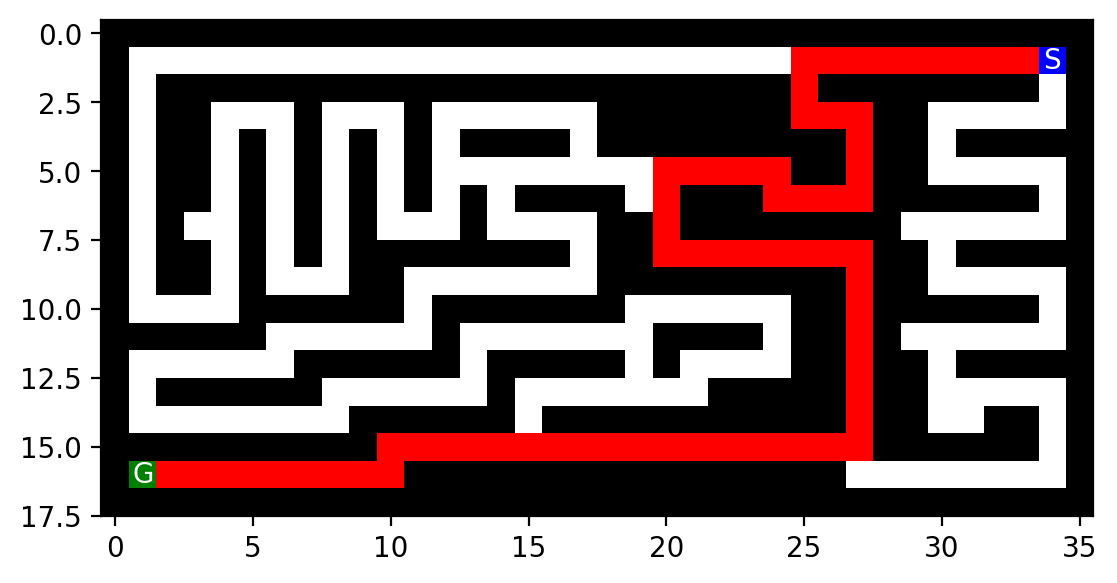

DFS Path: [(np.int64(1), np.int64(34)), (np.int64(1), np.int64(33)), (np.int64(1), np.int64(32)), (np.int64(1), np.int64(31)), (np.int64(1), np.int64(30)), (np.int64(1), np.int64(29)), (np.int64(1), np.int64(28)), (np.int64(1), np.int64(27)), (np.int64(1), np.int64(26)), (np.int64(1), np.int64(25)), (np.int64(1), np.int64(24)), (np.int64(1), np.int64(23)), (np.int64(1), np.int64(22)), (np.int64(1), np.int64(21)), (np.int64(1), np.int64(20)), (np.int64(1), np.int64(19)), (np.int64(1), np.int64(18)), (np.int64(1), np.int64(17)), (np.int64(1), np.int64(16)), (np.int64(1), np.int64(15)), (np.int64(1), np.int64(14)), (np.int64(1), np.int64(13)), (np.int64(1), np.int64(12)), (np.int64(1), np.int64(11)), (np.int64(1), np.int64(10)), (np.int64(1), np.int64(9)), (np.int64(1), np.int64(8)), (np.int64(1), np.int64(7)), (np.int64(1), np.int64(6)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(1)), (np.int64(2)

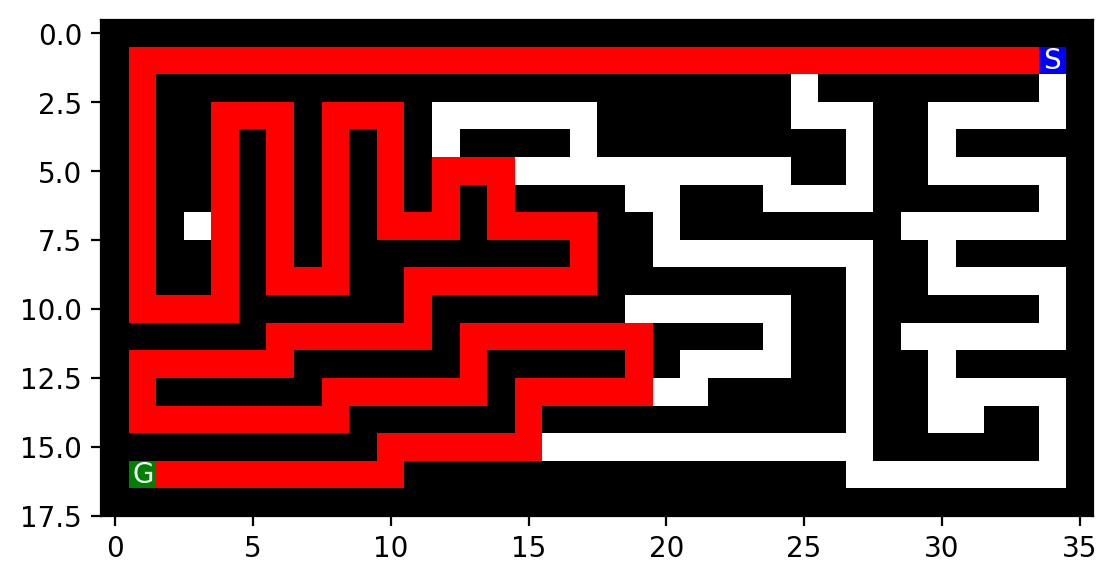

In [961]:
maze = mh.parse_maze(open("medium_maze.txt").read())
start = mh.find_pos(maze, "S")
goal = mh.find_pos(maze, "G")

def show_maze_with_path(maze, result):
    maze_copy = maze.copy()

    if result["solution"] is None:
      mh.show_maze(maze_copy)
      return
    path_nodes = result["solution"].get_path_from_root()

    for node in path_nodes:
        if maze_copy[node.pos] not in ('S', 'G'):
            maze_copy[node.pos] = 'P'

    mh.show_maze(maze_copy)

bfsResult = bfs(maze, start, goal)
print("BFS Path:", [n.pos for n in bfsResult["solution"].get_path_from_root()])
print("BFS Cost:", bfsResult["pathCost"])
print("BFS Nodes Expanded:", bfsResult["nodesExpanded"])
print("BFS Max Depth:", bfsResult["maxDepth"])
print("BFS Max Frontier Size:", bfsResult["maxFrontier"])
show_maze_with_path(maze, bfsResult)

dfsResult = dfs(maze, start, goal, limit=500)
if dfsResult["solution"] is not None:
    print("DFS Path:", [n.pos for n in dfsResult["solution"].get_path_from_root()])
    print("DFS Cost:", dfsResult["pathCost"])
    print("DFS Nodes Expanded:", dfsResult["nodesExpanded"])
    print("DFS Max Depth:", dfsResult["maxDepth"])
    print("DFS Max Frontier Size:", dfsResult["maxFrontier"])
    show_maze_with_path(maze, dfsResult)
else:
    print("\nDFS: No solution found within limit.")


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

In [962]:
# Discussion

* BFS: This model handles loops by using the reached strucuture which stores if a cell has been visited, and it will not revisit it again.
* DFS: This model handles loops without the reached structure by doing cycle checking, where it sees if the child is somewhere in the path that the agent is currently on. This is checking only the current path and the model doesnt store memory, so it can end up revisiting cells from other paths previously done.

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

In [963]:
# Discussion

* BFS: This model is both complete and optimal. It is complete because it never revisits and finds the solution. It is optimal because it always finds the shortest path. The time complexity is O(b^d) and the space complexity is O(b^d).
* DFS: This model is neither complete or optimal. It is not complete in infinite spaces, such as the open maze where it runs infinitly. It is not optimal because it returns the first path it finds, which is most likely not the shortest path. The time complexity is O(b^m) and the space complexity is O(bm).
* THe difference in space complexity, it is better in DFS as it doesnt have memory and doesnt use the reached structure.  

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides).

In [964]:
# Your code goes here
import heapq

counter = 0

def manhattan(pos, goal):
  return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def greedy(maze, start, goal):
  global counter
  counter = 0

  root = Node(pos=start, parent=None, action=None, cost=0)
  if root.pos == goal:
      return {
          "solution": root,
          "pathCost": root.cost,
          "nodesExpanded": 1,
          "maxDepth": 0,
          "maxFrontier": 1
      }

  frontier = []
  heapq.heappush(frontier, (manhattan(start, goal), counter, root))
  counter += 1
  reached = {start: root}
  nodesExpanded = 0
  maxFrontier = 1
  maxDepth = 0

  while frontier:
    maxFrontier = max(maxFrontier, len(frontier))
    _, _, node = heapq.heappop(frontier)
    nodesExpanded += 1
    maxDepth = max(maxDepth, node.cost)

    if node.pos == goal:
      return{
          "solution" : node,
          "pathCost" : node.cost,
          "nodesExpanded" : nodesExpanded,
          "maxDepth" : maxDepth,
          "maxFrontier" : maxFrontier
      }

    for child in expand(maze, node):
      s = child.pos
      if s not in reached or child.cost < reached[s].cost:
        reached[s] = child
        priority = manhattan(s, goal)
        heapq.heappush(frontier, (priority, counter, child))
        counter += 1

  return {
      "solution" : None,
      "pathCost" : None,
      "nodesExpanded" : nodesExpanded,
      "maxDepth" : maxDepth,
      "maxFrontier" : maxFrontier
  }


def astar(maze, start, goal):
    global counter
    counter = 0

    root = Node(pos=start, parent=None, action=None, cost=0)
    if root.pos == goal:
        return {
            "solution": root,
            "pathCost": root.cost,
            "nodesExpanded": 1,
            "maxDepth": 0,
            "maxFrontier": 1
        }

    frontier = []
    heapq.heappush(frontier, (manhattan(start, goal), counter, root))
    counter += 1
    reached = {start: root}
    nodesExpanded = 0
    maxFrontier = 1
    maxDepth = 0

    while frontier:
      maxFrontier = max(maxFrontier, len(frontier))
      _, _, node = heapq.heappop(frontier)
      nodesExpanded += 1
      maxDepth = max(maxDepth, node.cost)

      if node.pos == goal:
        return{
          "solution" : node,
          "pathCost" : node.cost,
          "nodesExpanded" : nodesExpanded,
          "maxDepth" : maxDepth,
          "maxFrontier" : maxFrontier
        }

      for child in expand(maze, node):
        s = child.pos
        g = child.cost
        h = manhattan(s, goal)
        f = g + h

        if s not in reached or g < reached[s].cost:
          reached[s] = child
          heapq.heappush(frontier, (f, counter, child))
          counter += 1

    return{
        "solution" : None,
        "pathCost" : None,
        "nodesExpanded" : nodesExpanded,
        "maxDepth" : maxDepth,
        "maxFrontier" : maxFrontier
    }

Greedy Cost: 74
Greedy Nodes Expanded: 79
Greedy Max Depth: 74
Greedy Max Frontier: 4


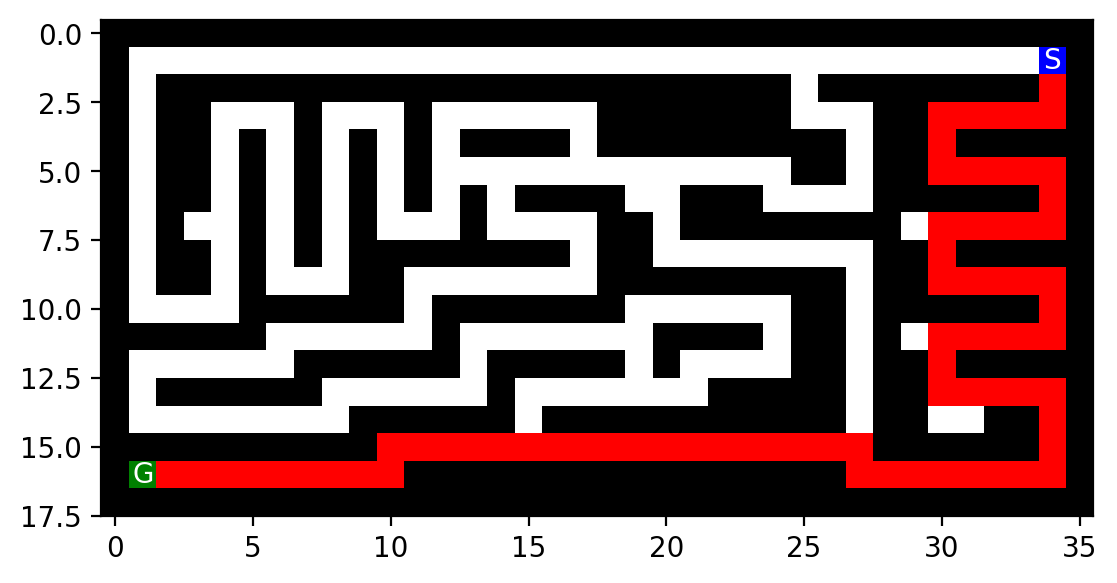

A* Path Cost: 68
A* Nodes Expanded: 223
A* Max Depth: 68
A* Max Frontier: 8


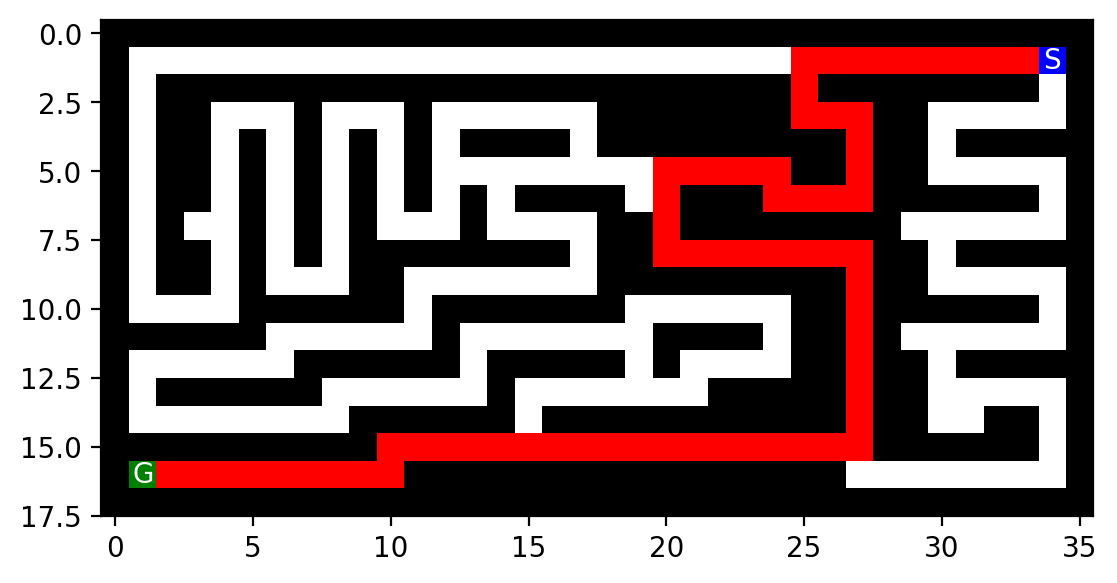

In [965]:

greedyResult = greedy(maze, start, goal)
print("Greedy Cost:", greedyResult["pathCost"])
print("Greedy Nodes Expanded:", greedyResult["nodesExpanded"])
print("Greedy Max Depth:", greedyResult["maxDepth"])
print("Greedy Max Frontier:", greedyResult["maxFrontier"])
show_maze_with_path(maze, greedyResult)

astarResult = astar(maze, start, goal)
print("A* Path Cost:", astarResult["pathCost"])
print("A* Nodes Expanded:", astarResult["nodesExpanded"])
print("A* Max Depth:", astarResult["maxDepth"])
print("A* Max Frontier:", astarResult["maxFrontier"])
show_maze_with_path(maze, astarResult)


Are your implementations complete and optimal? What is the time and space complexity?

In [966]:
# Discussion

* Greedy: This model is complete but not optimal. It is complete because it never revisits and it finds the solution. It is not optimal because it ignores path cost and will often find a longer path. The time complexity is O(b^m), and the space complexity is O(b^m).
* A*: This model is complete and optimal. It is complete because it will always find a solution. It is optimal because it always finds the shortest path because of the heuristic. The time complexity is O(b^d), and the space compelxity is O(b^d)

## Task 4: Comparison and discussion [20 Points]

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [967]:
# Add code

In [968]:
import pandas as pd
import matplotlib.pyplot as plt

def algos(algorithm, maze, start, goal, name, limit = None):
  if limit is not None:
    result = algorithm(maze, start, goal, limit)
  else:
    result = algorithm(maze, start, goal)

  if result["solution"] is None:
    return {
        "algorithm" : name,
        "pathCost" : None,
        "nodesExpanded" : None,
        "maxDepth" : None,
        "maxFrontier" : None
    }

  return{
      "algorithm" : name,
      "pathCost" :  result["pathCost"],
      "nodesExpanded" : result["nodesExpanded"],
      "maxDepth" : result["maxDepth"],
      "maxFrontier" : result["maxFrontier"]
  }

def table(results):
  return pd.DataFrame(results)

mazes = [
    "large_maze.txt",
    "medium_maze.txt",
    "small_maze.txt",
    "loops_maze.txt",
    "L_maze.txt",
    "empty_maze.txt",
    "empty_maze_2.txt",
    "open_maze.txt"
]

for maze in mazes:
  mazeRun = mh.parse_maze(open(maze).read())
  start = mh.find_pos(mazeRun, "S")
  goal = mh.find_pos(mazeRun, "G")
  results = []

  results.append(algos(bfs, mazeRun, start, goal, "BFS"))

  if maze == "open_maze.txt":
    results.append({
        "algorithm" : "DFS",
        "pathCost" : "N/A",
        "nodesExpanded" : "N/A",
        "maxDepth" : "N/A",
        "maxFrontier" : "N/A"
    })
  else:
    results.append(algos(dfs, mazeRun, start, goal, "DFS", limit = 500))

  results.append(algos(greedy, mazeRun, start, goal, "Greedy"))
  results.append(algos(astar, mazeRun, start, goal, "A*"))

  df = table(results)
  print(maze, ": ")
  display(df)


large_maze.txt : 


,algorithm,pathCost,nodesExpanded,maxDepth,maxFrontier
0,BFS,210,622,210,8
1,DFS,210,338,214,38
2,Greedy,210,467,210,21
3,A*,210,550,210,12


medium_maze.txt : 


,algorithm,pathCost,nodesExpanded,maxDepth,maxFrontier
0,BFS,68,270,68,9
1,DFS,152,154,152,8
2,Greedy,74,79,74,4
3,A*,68,223,68,8


small_maze.txt : 


...

,algorithm,pathCost,nodesExpanded,maxDepth,maxFrontier
0,BFS,14,96,14,12
1,DFS,80,81,80,73
2,Greedy,14,15,14,29
3,A*,14,64,14,31


empty_maze_2.txt : 


,algorithm,pathCost,nodesExpanded,maxDepth,maxFrontier
0,BFS,14,96,14,11
1,DFS,34,35,34,42
2,Greedy,14,15,14,29
3,A*,14,64,14,31


open_maze.txt : 


,algorithm,pathCost,nodesExpanded,maxDepth,maxFrontier
0,BFS,54,683,54,25
1,DFS,N/A,N/A,N/A,N/A
2,Greedy,68,90,68,66
3,A*,54,536,54,25


Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)).

In [969]:
# Add charts

large_maze.txt : 


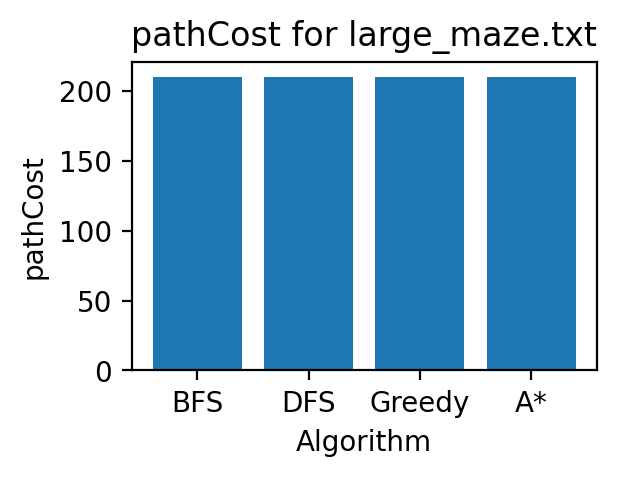

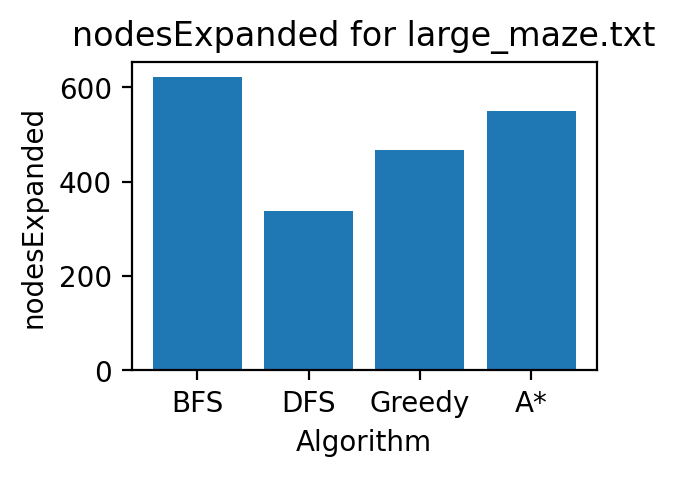

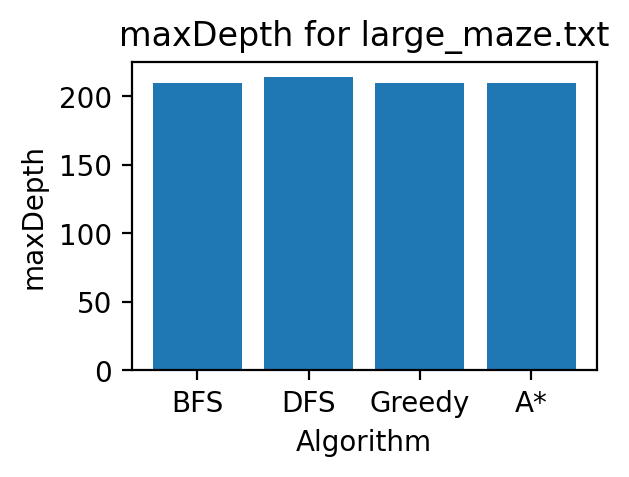

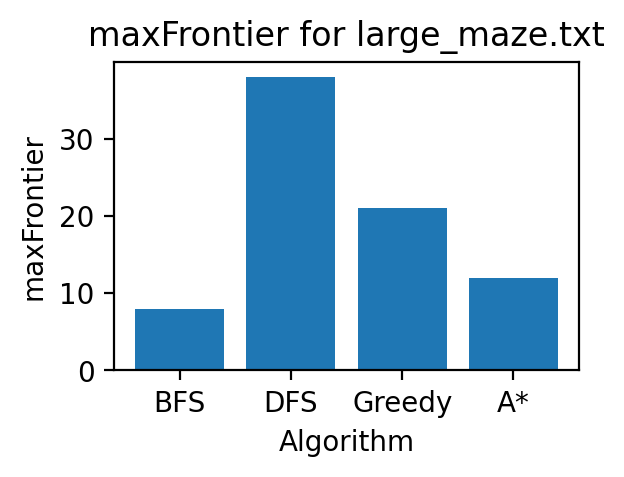

medium_maze.txt : 


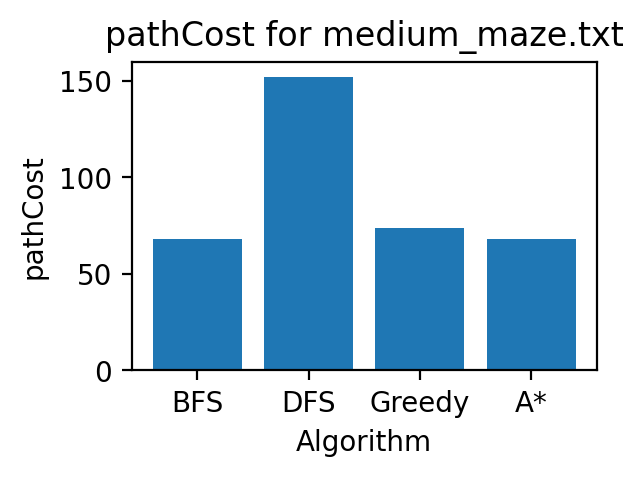

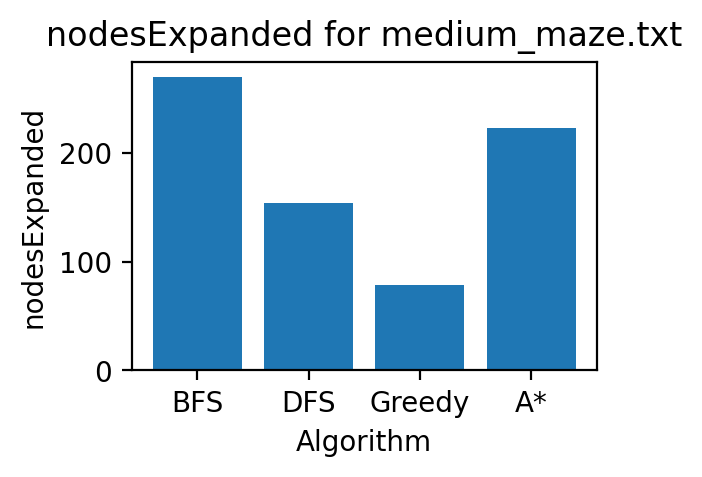

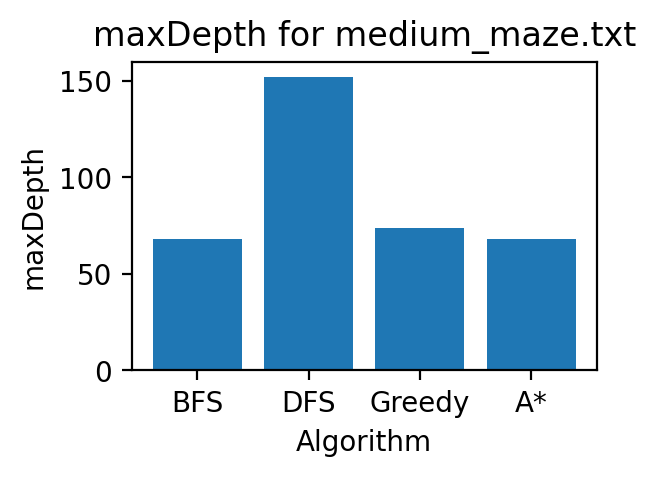

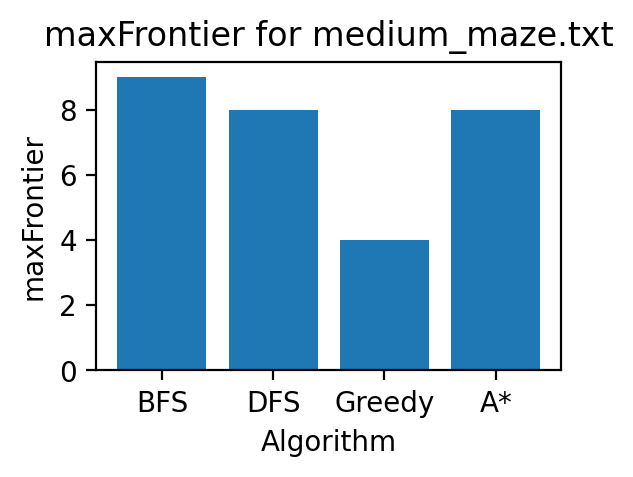

small_maze.txt : 


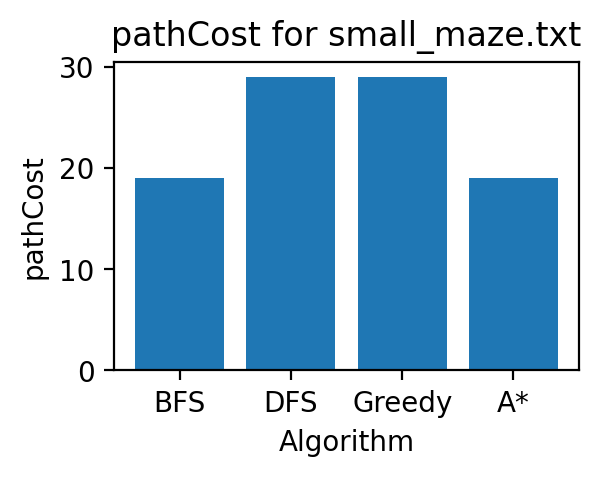

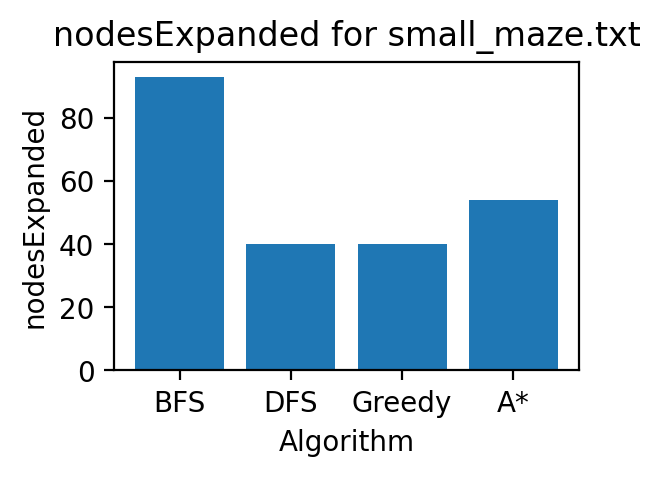

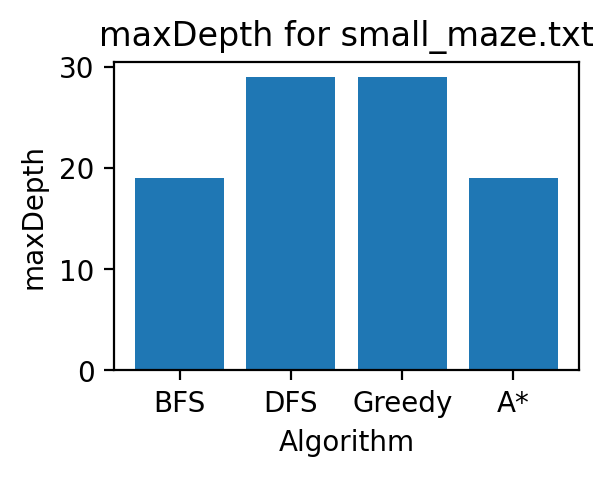

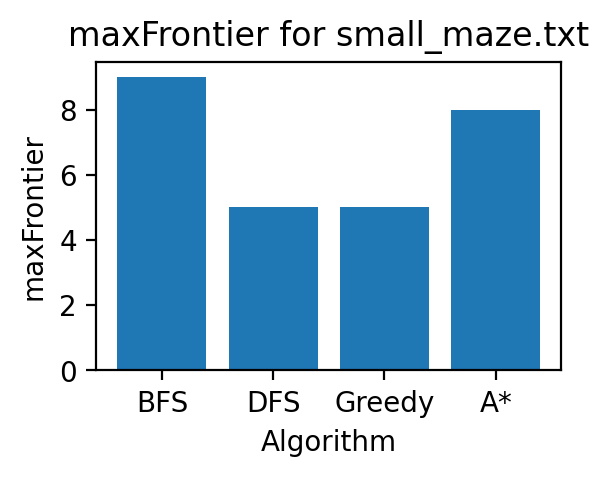

loops_maze.txt : 


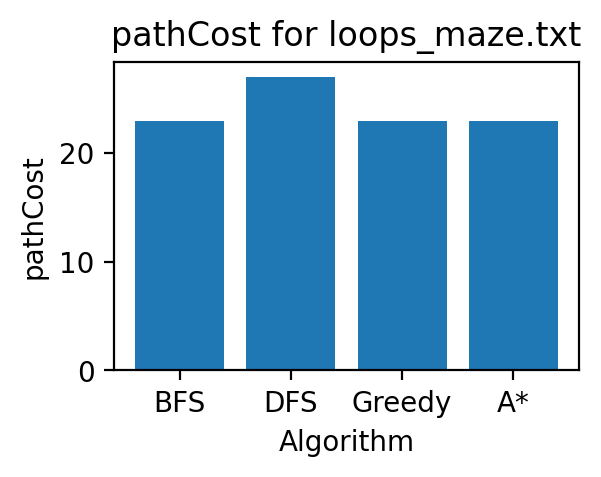

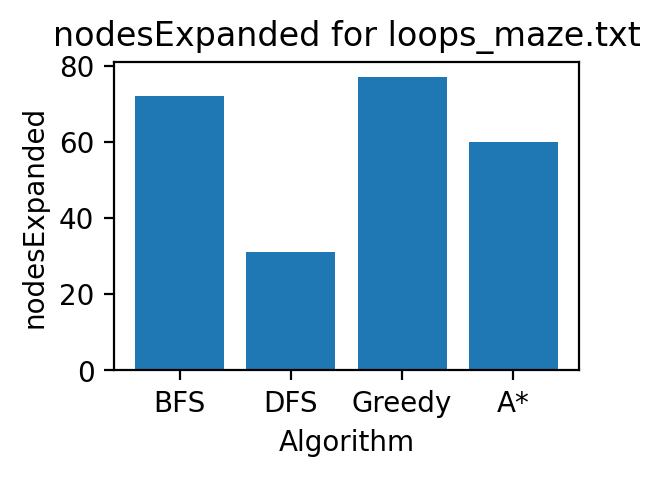

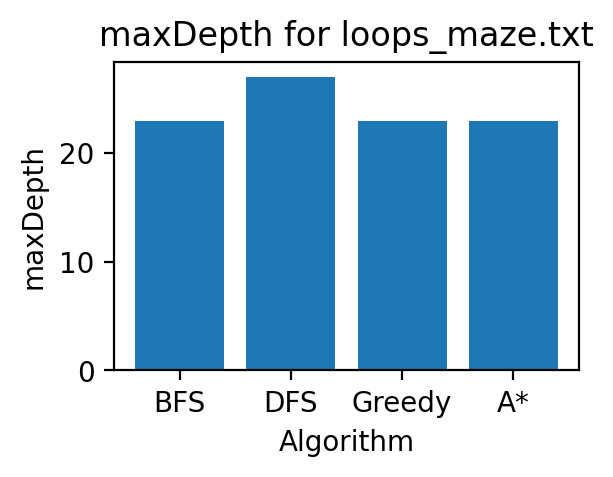

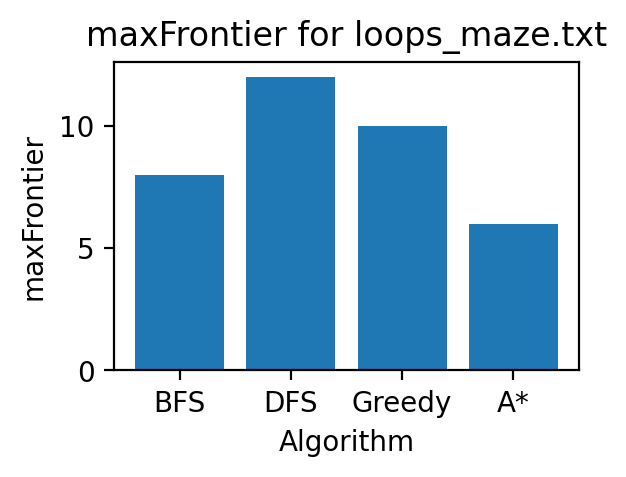

L_maze.txt : 


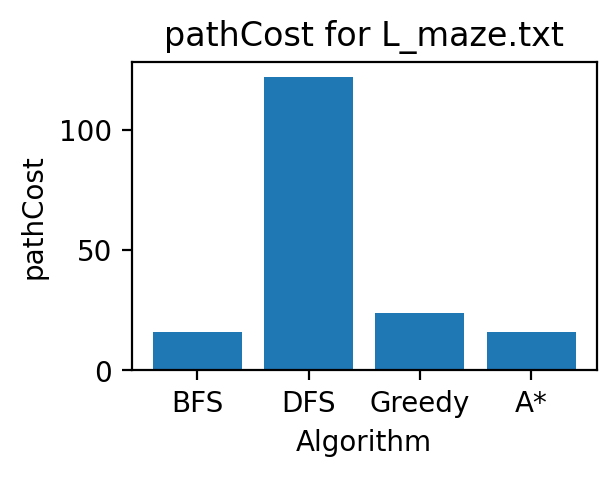

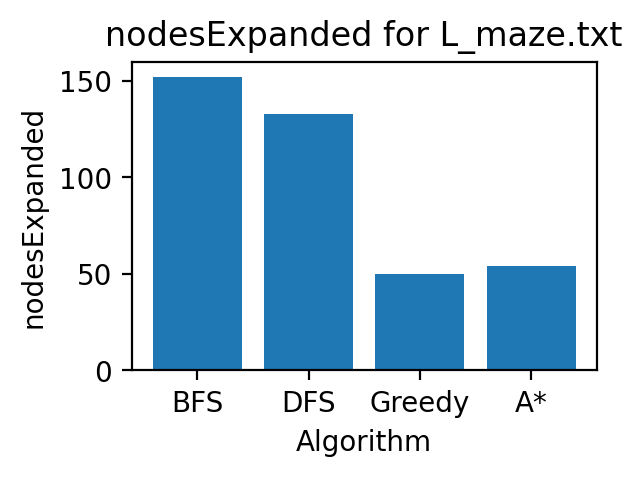

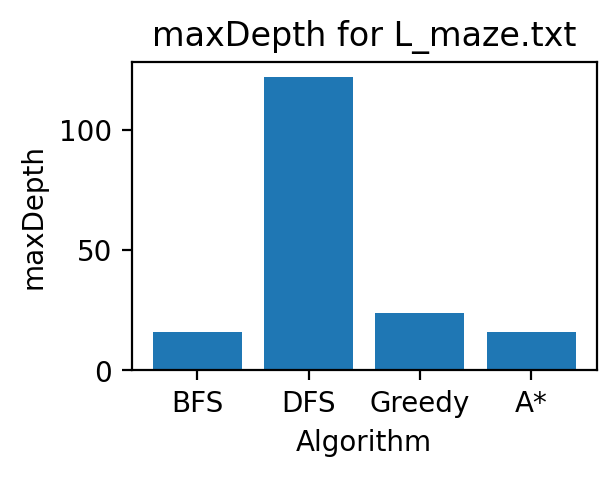

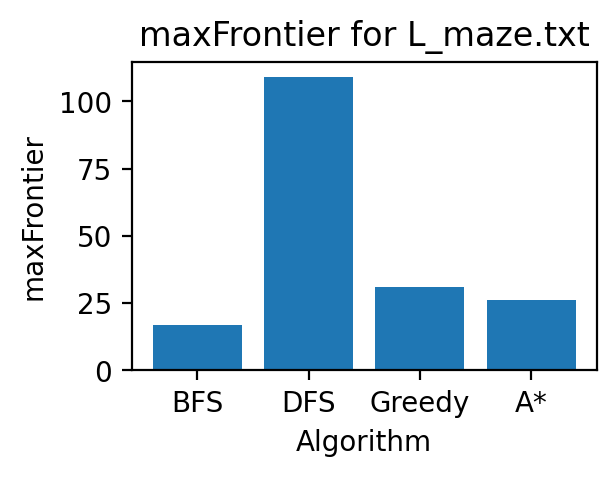

empty_maze.txt : 


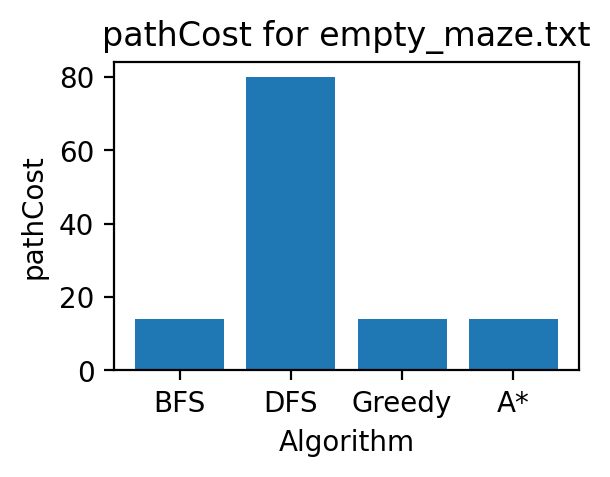

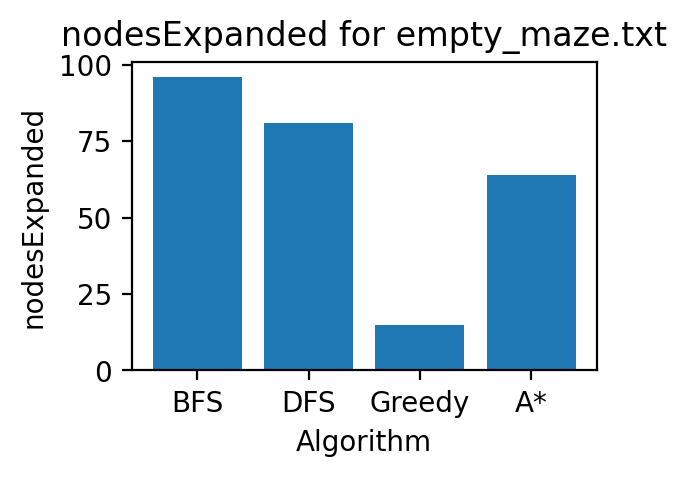

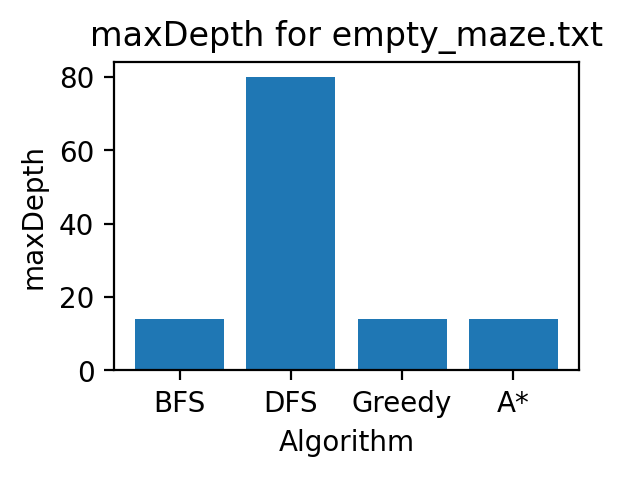

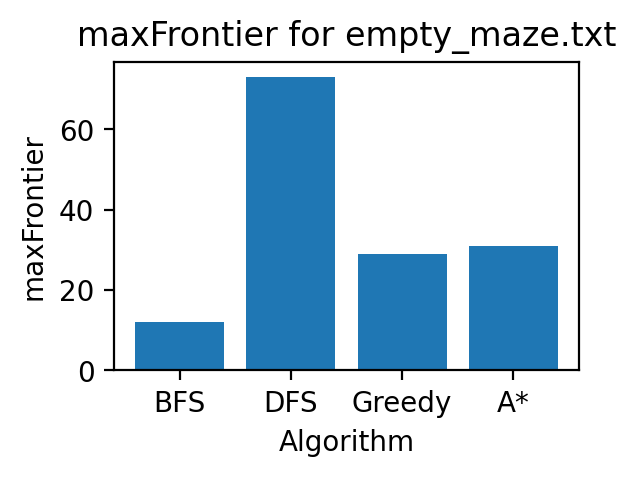

empty_maze_2.txt : 


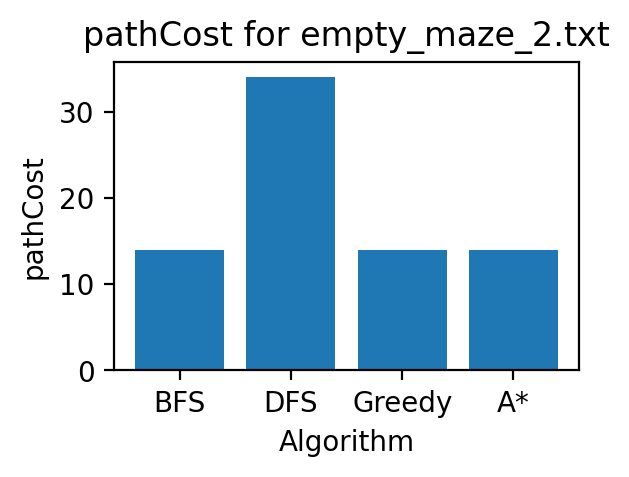

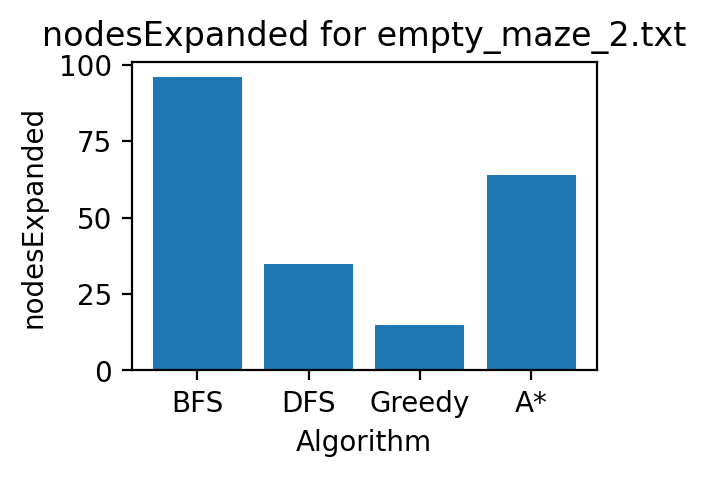

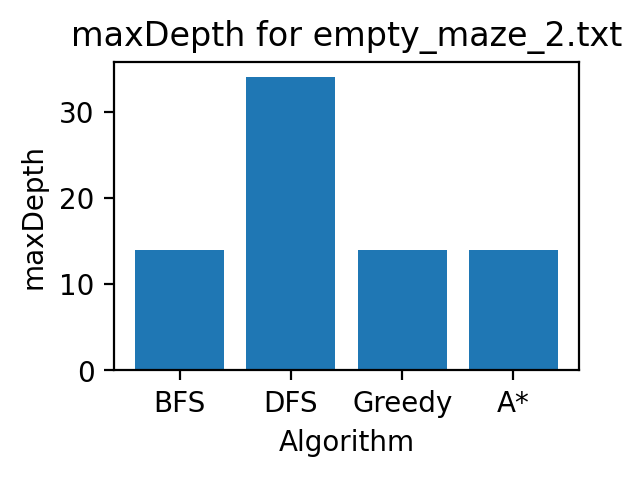

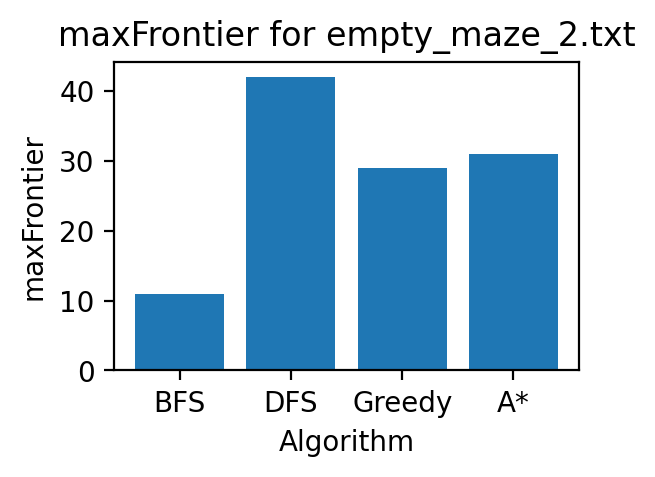

open_maze.txt : 


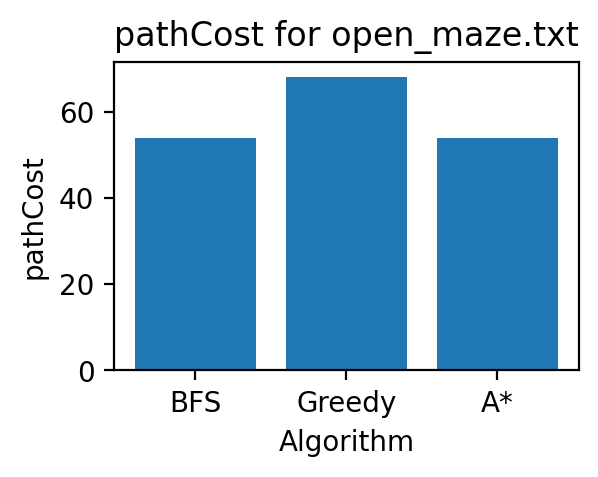

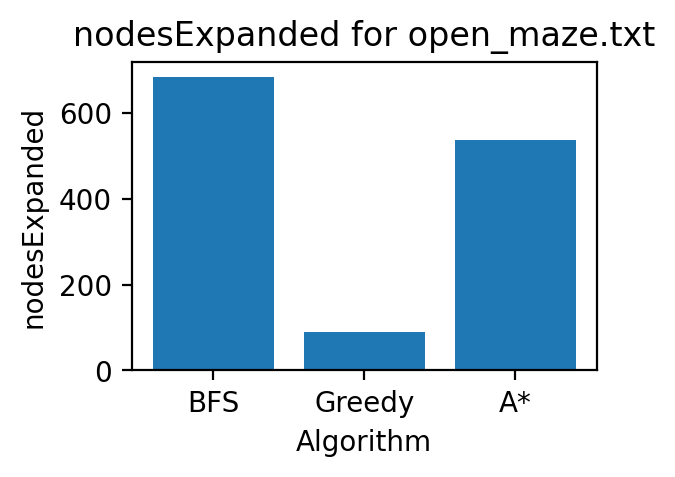

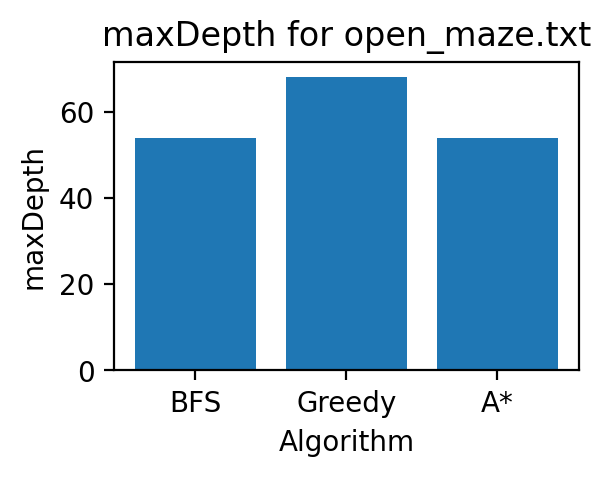

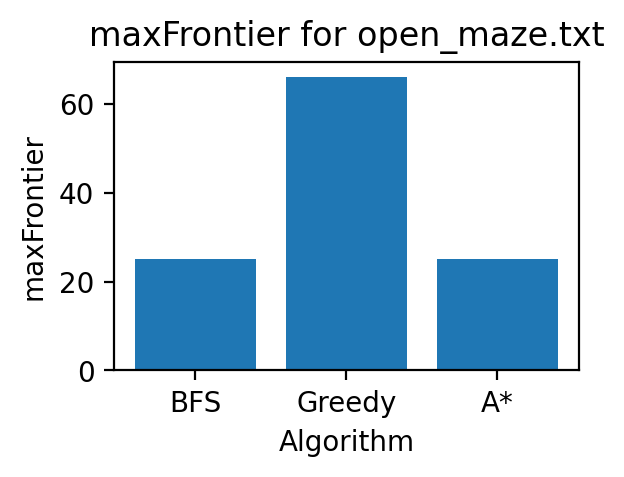

In [970]:
import matplotlib.pyplot as plt

def plot(df, metric, maze_name):
  plt.figure(figsize=(3, 2))
  plt.bar(df["algorithm"], df[metric])
  plt.xlabel("Algorithm")
  plt.title(f"{metric} for {maze_name}")
  plt.ylabel(metric)
  plt.show()

for maze in mazes:
  mazeRun = mh.parse_maze(open(maze).read())
  start = mh.find_pos(mazeRun, "S")
  goal = mh.find_pos(mazeRun, "G")
  results = []

  results.append(algos(bfs, mazeRun, start, goal, "BFS"))

  if maze == "open_maze.txt":
    results.append({
        "algorithm" : "DFS",
        "pathCost" : "N/A",
        "nodesExpanded" : "N/A",
        "maxDepth" : "N/A",
        "maxFrontier" : "N/A"
    })
  else:
    results.append(algos(dfs, mazeRun, start, goal, "DFS", limit = 500))

  results.append(algos(greedy, mazeRun, start, goal, "Greedy"))
  results.append(algos(astar, mazeRun, start, goal, "A*"))

  df = table(results)
  print(maze, ": ")
  dfN = df[df["pathCost"] != "N/A"]
  plot(dfN, "pathCost", maze)
  plot(dfN, "nodesExpanded", maze)
  plot(dfN, "maxDepth", maze)
  plot(dfN, "maxFrontier", maze)


Discuss the most important lessons you have learned from implementing the different search strategies.

In [971]:
# Add discussion

* The biggest lesson I learned from implementing these strategies was being able to see the differnece in optimality and space. For example, even though DFS didnt use a lot of memory, it was way less efficient as compared to the others. As well, seeing the difference between greedy and a* based on how it used the heuristic was also important, as you can see it makes a difference in a* when you are not relying solely on the heuristic.
* Another lesson I learned how siginificantg of a difference the reached function makes between BFS and DFS. Seeing just how much longer DFS takes and how it can get stuck without the reached, helped me really understand the difference.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [972]:
# Your code/answer goes here

### Multiple Goals
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [973]:
# Your code/answer goes here

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [974]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [975]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [976]:
# Your code/answer goes here

# Task
Modify the `greedy` function to resolve the `TypeError` by adding a global counter as a tie-breaker to the `heapq.heappush` calls, ensuring `Node` objects are not directly compared.

## Modify greedy function

### Subtask:
Re-introduce a tie-breaker (a global counter) to the `heapq.heappush` calls in the `greedy` function to prevent `Node` objects from being compared directly.


## Summary:

### Data Analysis Key Findings
*   A `TypeError` was encountered during the execution of the `greedy` function due to direct comparison of `Node` objects within `heapq.heappush` operations.
*   To resolve this, a global counter was introduced as a tie-breaker, which is included in the tuple pushed onto the heap.

### Insights or Next Steps
*   This approach effectively bypasses the direct comparison of `Node` objects by leveraging the stability of `heapq` when elements are tuples, where the first elements (priority and tie-breaker) dictate order.
*   The next step is to execute the modified `greedy` function to confirm that the `TypeError` is resolved and that the function behaves as expected for its intended purpose.
